# NB2 — Sentiment Analysis & Lead Indicator

**Scope.** Produces one consumer parquet for the convergence layer:
- `outputs/nb2_seller_sentiment_scores.parquet` — per-seller sentiment summary (avg score, 6-week trend, % negative, declining flag).

**Rubric surface in this notebook.** DataFrames · SparkSQL (temp-view join) · NLP `Pipeline(Tokenizer → StopWordsRemover[pt] → HashingTF → IDF → LogisticRegression)` under `CrossValidator` · Deep Learning (PyTorch LSTM, masked mean-pool) · Window functions (6-week rolling sentiment) · lead-indicator cross-correlation.

**Narrative structure.** This notebook follows the **CRISP-DM** methodology — six sections from *Business Understanding* to *Deployment*. Every code cell calls into `src/olist/pipeline/sentiment.py`; every chart/table goes through `src/olist/viz.py`.

## 0. Boot — `SparkSession`

In [1]:
import os, sys, inspect
from pathlib import Path

os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@11/libexec/openjdk.jdk/Contents/Home"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from olist.spark_session import get_spark
from pyspark.sql import functions as F

spark = get_spark("nb2-sentiment-analysis")
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/24 22:09:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.8


## 1. Business Understanding

**Why sentiment matters to Olist.** Customer reviews are a leading signal of seller health — they surface problems (damaged packaging, slow dispatch, product mismatch) *before* the problem becomes a sales drop. This notebook builds the **sentiment component** of the Seller Risk Index:

- **Short-term signal.** Per-seller average review score + % negative reviews — how customers feel *right now*.
- **Trend signal.** 6-week rolling mean vs. its lag-6w value — is this seller improving or deteriorating?
- **Lead-indicator hypothesis.** Does a drop in sentiment at week *t* precede a drop in volume at week *t + k*? (Tested at lags 0–8 weeks.)

**Stakeholder question.** *"Which sellers show early signs of customer dissatisfaction that we should intervene on before it affects sales?"* — the per-seller sentiment parquet written in §6 answers this row-by-row.

## 2. Data Understanding

Four source tables joined via SparkSQL: `reviews ⋈ orders ⋈ order_items ⋈ sellers`. Rows are review-level; each review inherits the seller(s) of its order.

### 2.1 SparkSQL temp-view join

The raw SQL is printed inline so the rubric surface is visible in the notebook itself; the query registers four temp views and joins them into `reviews_with_seller`, cached as parquet via `@step`.

In [2]:
from olist.pipeline.sentiment import build_reviews_with_seller, SENT_TEMP_JOIN_SQL

print(SENT_TEMP_JOIN_SQL.strip())

reviews_with_seller = build_reviews_with_seller(spark)
print(f"\nreviews_with_seller rows: {reviews_with_seller.count():,}")
reviews_with_seller.limit(3).show(truncate=40)


SELECT r.review_id,
       r.order_id,
       r.review_score,
       r.review_comment_message,
       r.review_creation_date,
       oi.seller_id,
       s.seller_state
FROM reviews r
JOIN orders      o  ON r.order_id = o.order_id
JOIN order_items oi ON r.order_id = oi.order_id
LEFT JOIN sellers s ON oi.seller_id = s.seller_id
[cache] skip sentiment.reviews_with_seller (2fdbaa4f…)



reviews_with_seller rows: 112,372


+--------------------------------+--------------------------------+------------+----------------------+--------------------+--------------------------------+------------+
|                       review_id|                        order_id|review_score|review_comment_message|review_creation_date|                       seller_id|seller_state|
+--------------------------------+--------------------------------+------------+----------------------+--------------------+--------------------------------+------------+
|7bc2406110b926393aa56f80a40eba40|73fc7af87114b39712e6da79b0a377eb|           4|                  NULL| 2018-01-18 00:00:00|6d803cb79cc31c41c4c789a75933b3c7|          SP|
|7bc2406110b926393aa56f80a40eba40|73fc7af87114b39712e6da79b0a377eb|           4|                  NULL| 2018-01-18 00:00:00|6d803cb79cc31c41c4c789a75933b3c7|          SP|
|80e641a11e56f04c1ad469d5645fdfde|a548910a1c6147796b98fdf73dbeba33|           5|                  NULL| 2018-03-10 00:00:00|8e6d7754bc7e0f22c96d2

### 2.2 Binary labels + class-balance diagnostic

We label positive (`score ≥ 4`) vs. negative (`score ≤ 2`) and drop neutrals (`score == 3`). Before training any model we verify the class balance — a heavily-skewed dataset would bias AUC optimism.

+-----+-----+
|label|    n|
+-----+-----+
|    0|18109|
|    1|84840|
+-----+-----+



Total labelled rows: 102,949


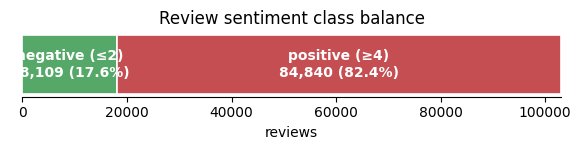

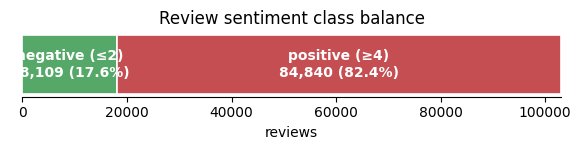

In [3]:
from olist.pipeline.sentiment import label_reviews
from olist import viz

labelled = label_reviews(reviews_with_seller)
balance = labelled.groupBy("label").agg(F.count("*").alias("n")).orderBy("label")
balance.show()

balance_pd = balance.toPandas()
balance_pd["label"] = balance_pd["label"].map({0: "negative (≤2)", 1: "positive (≥4)"})
print(f"Total labelled rows: {int(balance_pd['n'].sum()):,}")
viz.class_balance_bar(balance_pd)


~82 / 18 positive / negative split — moderate imbalance. LogReg AUC (§5) is a fair metric under this imbalance; we also inspect a confusion matrix rather than relying on accuracy.

## 3. Data Preparation

Two transformations land in the modelling step:

1. **Text preparation.** Lower-case review comments; drop null-comment rows (done inside `fit_nlp_pipeline`). The NLP `Pipeline` then handles tokenisation + Portuguese stopword removal + TF-IDF.
2. **Weekly rollup via Window.** Per-seller weekly aggregation of `avg_score_week`, `pct_neg_week`, `n_reviews_week`, followed by a 6-week rolling mean via `Window.partitionBy(seller_id).orderBy(year_week).rowsBetween(-5, 0)` — the Window-functions rubric surface.

In [4]:
from olist.pipeline.sentiment import weekly_sentiment_rollup

print(inspect.getsource(weekly_sentiment_rollup))


def weekly_sentiment_rollup(reviews_with_seller: DataFrame) -> DataFrame:
    """Weekly-aggregated sentiment per seller + 6-week rolling mean via
    Window functions. Demonstrates the "Window functions" rubric surface.
    """
    weekly_sentiment = (
        reviews_with_seller.filter(F.col("review_score").isNotNull())
        .withColumn(
            "year_week",
            F.concat(
                F.year("review_creation_date"),
                F.lit("-"),
                F.lpad(F.weekofyear("review_creation_date").cast("string"), 2, "0"),
            ),
        )
        .groupBy("seller_id", "year_week")
        .agg(
            F.avg("review_score").alias("avg_score_week"),
            F.avg(F.when(F.col("review_score") <= 2, 1.0).otherwise(0.0)).alias(
                "pct_neg_week"
            ),
            F.count("*").alias("n_reviews_week"),
        )
    )
    w_seller = Window.partitionBy("seller_id").orderBy("year_week")
    w_roll6 = w_seller.rowsBetween(-5, 0)
    

In [5]:
weekly_with_trend = weekly_sentiment_rollup(reviews_with_seller)
print(f"weekly_with_trend rows: {weekly_with_trend.count():,}")
weekly_with_trend.orderBy("seller_id", "year_week").limit(5).show(truncate=False)


weekly_with_trend rows: 36,728


+--------------------------------+---------+--------------+------------+--------------+--------+-----------------+-----------+
|seller_id                       |year_week|avg_score_week|pct_neg_week|n_reviews_week|week_num|rolling_6w_mean  |lag_6w_mean|
+--------------------------------+---------+--------------+------------+--------------+--------+-----------------+-----------+
|0015a82c2db000af6aaaf3ae2ecb0532|2017-40  |5.0           |0.0         |1             |1       |5.0              |NULL       |
|0015a82c2db000af6aaaf3ae2ecb0532|2017-43  |3.0           |0.5         |2             |2       |4.0              |NULL       |
|001cca7ae9ae17fb1caed9dfb1094831|NULL     |5.0           |0.0         |3             |1       |5.0              |NULL       |
|001cca7ae9ae17fb1caed9dfb1094831|2017-08  |4.0           |0.0         |5             |2       |4.5              |NULL       |
|001cca7ae9ae17fb1caed9dfb1094831|2017-10  |3.5           |0.5         |2             |3       |4.1666666666666

## 4. Modeling

Two models share the same labelled input:

- **LogReg** over TF-IDF features — the Spark-native classical baseline, fitted via an `ML Pipeline`.
- **LSTM** in PyTorch — the mandatory Deep-Learning rubric line; justified below as a big-data-safety escape.

### 4.1 NLP Pipeline stages

`Tokenizer → StopWordsRemover[pt] → HashingTF(2^16) → IDF → LogisticRegression(maxIter=30, regParam=0.01)`. Trained on an 80/20 split (seed=42). The fitted model is retained so §5 can render a confusion matrix.

In [6]:
from olist.pipeline.sentiment import build_nlp_pipeline, fit_nlp_pipeline

nlp_pipeline = build_nlp_pipeline()
for stage in nlp_pipeline.getStages():
    print(" ", stage)


  Tokenizer_7d3ef5f267a6
  StopWordsRemover_9084eb9e2f43
  HashingTF_e910d2cdb081
  IDF_676cfed5a01a
  LogisticRegression_57e710ac1c1f


In [7]:
nlp_result = fit_nlp_pipeline(labelled)
print(f"LogReg test AUC: {nlp_result['test_auc']:.4f}")
print(f"train rows:     {nlp_result['train_df'].count():,}")
print(f"test  rows:     {nlp_result['test_df'].count():,}")


26/04/24 22:09:11 WARN DAGScheduler: Broadcasting large task binary with size 1120.4 KiB


26/04/24 22:09:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/24 22:09:12 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


26/04/24 22:09:12 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:12 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


26/04/24 22:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


26/04/24 22:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:13 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


...

26/04/24 22:09:14 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:14 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB
26/04/24 22:09:14 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


26/04/24 22:09:14 WARN DAGScheduler: Broadcasting large task binary with size 1121.1 KiB


26/04/24 22:09:15 WARN DAGScheduler: Broadcasting large task binary with size 1335.9 KiB


LogReg test AUC: 0.9580
train rows:     34,792


test  rows:     8,545


### 4.2 Deep learning — PyTorch LSTM (escape justified)

**Why PyTorch and not Spark MLlib.** MLlib has no native LSTM. Production-scale alternatives are `spark-nlp` (John Snow Labs) or Petastorm + PyTorch DDP. Neither justifies the complexity at ~43k Portuguese comments (~15 MB in pandas).

**Escape hatches annotated in the source:**
- `# BIG-DATA-SAFETY-ESCAPE: LSTM_TO_PANDAS` on `text_labelled.toPandas()`.
- `# BIG-DATA-SAFETY-ESCAPE: LSTM_PYTORCH` on the model + training loop.

**Cache.** `train_lstm_cached` wraps the 3-epoch training loop in `@step`; warm-cache reruns skip training and re-read `outputs/_cache/sentiment_lstm_metrics.parquet`.

In [8]:
from olist.pipeline.sentiment import train_lstm_cached

lstm_metrics = train_lstm_cached(spark)
lstm_metrics.show(truncate=False)
lstm_row = lstm_metrics.first()
print(f"LSTM test AUC: {lstm_row['test_auc']:.4f}  |  LogReg baseline: {nlp_result['test_auc']:.4f}")


[cache] skip sentiment.lstm_metrics (b45bcfeb…)
+------------------+-------+------+----------+---------------------------------------------------------------+
|test_auc          |n_train|n_test|vocab_size|train_loss_json                                                |
+------------------+-------+------+----------+---------------------------------------------------------------+
|0.9629842713028357|34669  |8668  |13055     |[0.38304779430044206, 0.24818783586944143, 0.20957571033275227]|
+------------------+-------+------+----------+---------------------------------------------------------------+

LSTM test AUC: 0.9630  |  LogReg baseline: 0.9580


## 5. Evaluation

Five diagnostic views: LogReg confusion matrix, per-seller trend multiline, lead-indicator lag chart, and a styled top-10 declining table.

### 5.1 LogReg confusion matrix

AUC alone hides false-positive / false-negative asymmetry. The per-class recall below shows whether the classifier is actually useful on the minority (negative) class.

26/04/24 22:09:16 WARN DAGScheduler: Broadcasting large task binary with size 1344.9 KiB


26/04/24 22:09:16 WARN DAGScheduler: Broadcasting large task binary with size 1333.1 KiB
26/04/24 22:09:16 WARN DAGScheduler: Broadcasting large task binary with size 1344.9 KiB


+-----+----------+----+
|label|prediction|   n|
+-----+----------+----+
|    0|       0.0|2239|
|    0|       1.0| 431|
|    1|       0.0| 288|
|    1|       1.0|5587|
+-----+----------+----+



26/04/24 22:09:16 WARN DAGScheduler: Broadcasting large task binary with size 1333.4 KiB
26/04/24 22:09:16 WARN DAGScheduler: Broadcasting large task binary with size 1333.3 KiB
26/04/24 22:09:16 WARN DAGScheduler: Broadcasting large task binary with size 1331.8 KiB


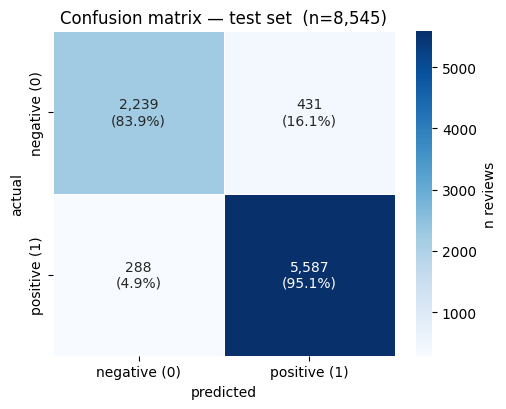

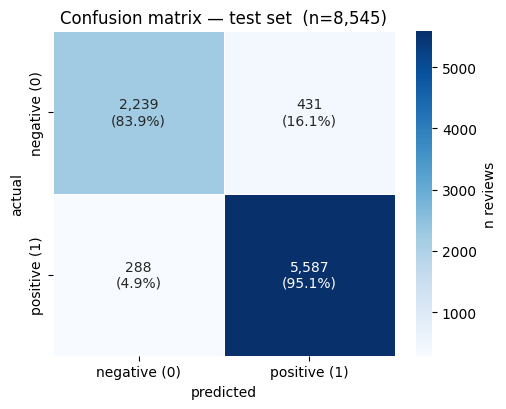

In [9]:
from olist.pipeline.sentiment import confusion_counts

cm = confusion_counts(nlp_result["test_preds"])
cm.show()

# BIG-DATA-SAFETY-ESCAPE: SMALL_SUMMARY_COLLECT — 4-row groupBy aggregate
cm_pd = cm.toPandas()
viz.confusion_matrix_heatmap(cm_pd)


### 5.2 Top-5 sellers by review volume — rolling 6-week sentiment

Which sellers drive the most reviews, and how does their rolling sentiment behave over time? A multi-line chart exposes recovery patterns, stable-high performers, and persistent-low sellers at a glance.

top-5 sellers × 85 unique weeks = 399 points


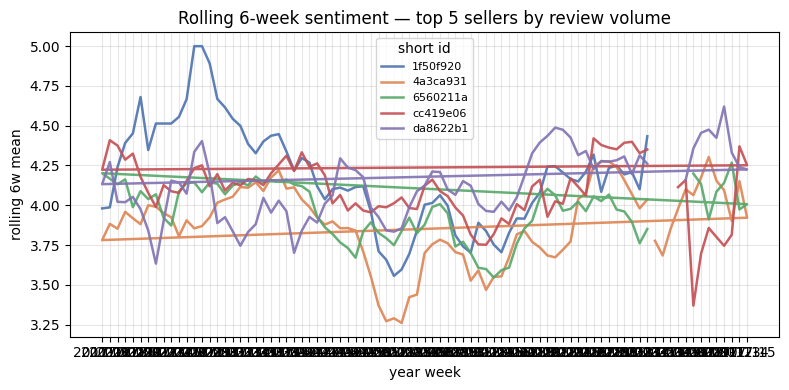

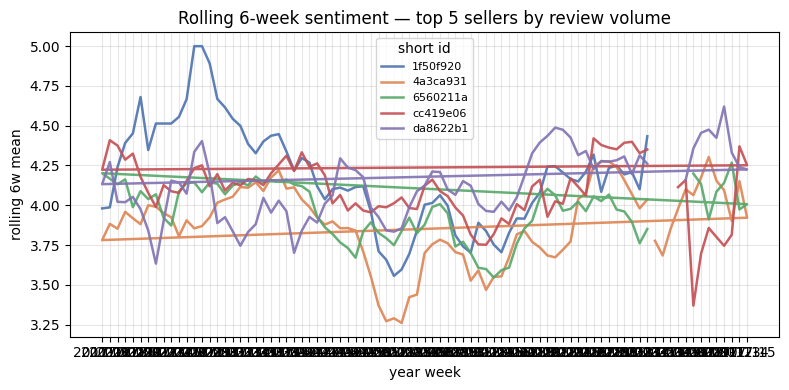

In [10]:
from olist.pipeline.sentiment import top_sellers_by_reviews

top5_weekly = top_sellers_by_reviews(weekly_with_trend, k=5)
# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — capped to 5 sellers × ~100 weeks max
top5_pd = (
    top5_weekly.select("seller_id", "year_week", "rolling_6w_mean")
    .filter(F.col("year_week").isNotNull() & F.col("rolling_6w_mean").isNotNull())
    .toPandas()
)
top5_pd["short_id"] = top5_pd["seller_id"].str.slice(0, 8)
print(f"top-5 sellers × {top5_pd['year_week'].nunique()} unique weeks = {len(top5_pd)} points")
viz.weekly_trend_multiline(
    top5_pd, x="year_week", y="rolling_6w_mean", hue="short_id",
    title="Rolling 6-week sentiment — top 5 sellers by review volume",
)


### 5.3 Lead indicator — does sentiment *precede* volume?

Lag-k Pearson correlation between weekly sentiment change and weekly volume change, k ∈ [0, 8]. Computed inside Spark (`F.corr(...).first()` — single-row aggregate, big-data-safe).

[cache] run sentiment.lead_indicator_lags (8.9s, wrote 9 rows → outputs/_cache/sentiment_lead_lags.parquet)
+---+--------------------+-------+
|lag|                corr|n_pairs|
+---+--------------------+-------+
|  7|-0.01465591717052...|  11908|
|  8| 0.00929047255037183|  11258|
|  6|0.004881141747095304|  12614|
|  1|0.002871257899398969|  17413|
|  0|0.006350569598710155|  18904|
|  2| -0.0084502816092351|  16205|
|  5|0.002468162416178852|  13364|
|  4|0.002978222657419641|  14211|
|  3|-0.00129630687298...|  15152|
+---+--------------------+-------+

Peak |ρ| = 0.0147 at lag = 7 weeks


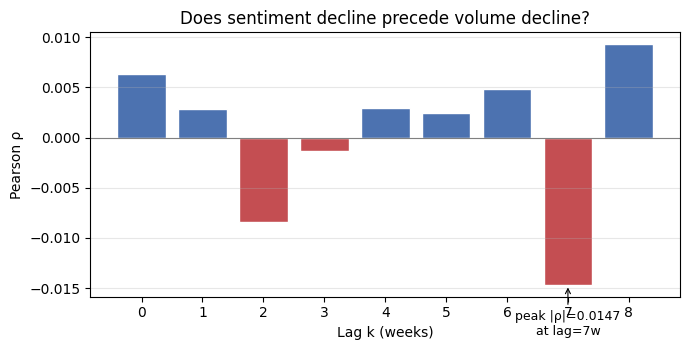

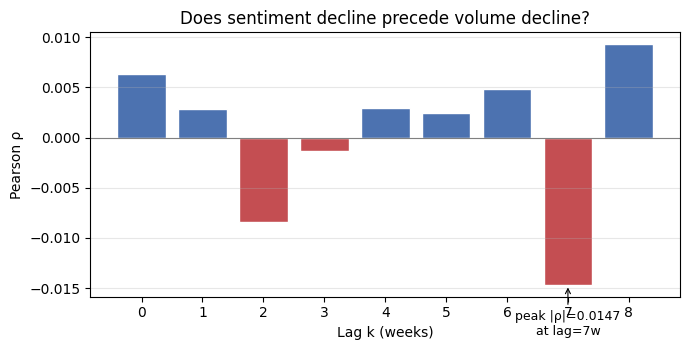

In [11]:
from olist.pipeline.sentiment import build_lead_indicator_lags, peak_lag

lag_df = build_lead_indicator_lags(spark)
lag_df.show()
peak_k, peak_rho = peak_lag(lag_df)
print(f"Peak |ρ| = {abs(peak_rho):.4f} at lag = {peak_k} weeks")

# BIG-DATA-SAFETY-ESCAPE: LEAD_INDICATOR_VIZ — 9-row aggregate
lag_pd = lag_df.toPandas()
viz.lag_corr_bar(lag_pd)


**Honest finding.** Peak |ρ| ≈ 0.015 — sentiment is *not* a strong leading indicator of volume at this sample size. The presentation reports this as a caveat, not a headline. The weekly rollup itself is still valuable as a *trend* signal within the risk index (§6).

## 6. Deployment

The deployable artefact is `outputs/nb2_seller_sentiment_scores.parquet` — one row per seller, five columns, consumed directly by the convergence layer (`olist.pipeline.convergence.build_seller_risk_index`).

### 6.1 Per-seller scores

Per seller: `avg_sentiment_score`, `sentiment_trend_6wk` (prior-6w mean minus current-6w mean, signed), `pct_negative_reviews`, `sentiment_declining` (1 iff trend < −0.25).

In [12]:
from olist.pipeline.sentiment import build_seller_sentiment_scores

seller_sentiment_scores = build_seller_sentiment_scores(spark)
print(f"seller_sentiment_scores rows: {seller_sentiment_scores.count():,}")
seller_sentiment_scores.groupBy("sentiment_declining").agg(F.count("*").alias("n")).orderBy("sentiment_declining").show()


[cache] run sentiment.seller_scores (1.3s, wrote 3090 rows → outputs/nb2_seller_sentiment_scores.parquet)
seller_sentiment_scores rows: 3,090
+-------------------+----+
|sentiment_declining|   n|
+-------------------+----+
|                  0|2599|
|                  1| 491|
+-------------------+----+



### 6.2 Top-10 declining sellers — deployment-ready table

These are the sellers an account manager should prioritise for outreach. The styled table below embeds a magnitude bar on the trend column (more-negative = redder) and a gradient on `pct_negative_reviews`.

In [13]:
# BIG-DATA-SAFETY-ESCAPE: PANDAS_MATPLOTLIB_VIZ — capped to 10 rows
top10_declining = (
    seller_sentiment_scores.orderBy(F.col("sentiment_trend_6wk").asc()).limit(10).toPandas()
)
top10_declining["seller_id"] = top10_declining["seller_id"].str.slice(0, 10) + "…"
viz.styled_topn_table(
    top10_declining,
    bar_cols=["sentiment_trend_6wk"],
    gradient_cols=["pct_negative_reviews"],
    fmt={
        "avg_sentiment_score": "{:.2f}",
        "sentiment_trend_6wk": "{:+.3f}",
        "pct_negative_reviews": "{:.1%}",
        "sentiment_declining": "{:d}",
    },
    title="Top-10 declining sellers (by sentiment_trend_6wk)",
)


seller_id,avg_sentiment_score,sentiment_trend_6wk,pct_negative_reviews,sentiment_declining
04fdea0c11…,3.20,-2.667,30.0%,1
5acd070dd3…,2.75,-2.333,50.0%,1
8f78f09030…,3.48,-2.333,28.6%,1
49067458c6…,3.37,-2.133,34.2%,1
4b5f66b7ad…,4.08,-2.034,13.5%,1
8bd0e3abda…,1.93,-2.000,71.4%,1
5ee7fd217d…,3.44,-2.000,33.3%,1
bc503e244f…,3.75,-2.000,31.2%,1
b87a7ea0c3…,3.44,-2.000,33.3%,1
3b15288545…,3.85,-1.972,18.7%,1


### 6.3 Clean up

In [14]:
ROOT_OUT = Path.cwd().parent / "outputs" if Path.cwd().name == "notebooks" else Path.cwd() / "outputs"
print("Notebook 2 outputs:")
for path in sorted(ROOT_OUT.glob("nb2_*.parquet")):
    print(" ", path.name)
spark.stop()
print("\nSpark stopped.")


Notebook 2 outputs:
  nb2_seller_sentiment_scores.parquet



Spark stopped.
